In [212]:
using Pkg
Pkg.activate(".")

using Revise
using LinearAlgebra
using Base.Iterators
import DictionaryLearning.FoldyLax as FL
using Plots
using Base.Threads
using CUDA, Adapt, KernelAbstractions

include("../debug.jl")
;

  Activating project at `~/DictionaryLearning/examples/foldy-lax`


## Settings & Setup

In [213]:
# settings
if CUDA.functional()
    back = CUDABackend()
    println("$INF using Cuda")
else
    back = CPU()
    println("$INF using CPU")
end

# frequencies
f0 = 5e9        # central frequency
B = 1e9         # bandwidth
df = 40e6       # frequency resolution
λ = 3e8/f0

println("$INF central wavelength: $λ")

# recievers
r = zeros(3, 31)
r[1, :] .= -14.0
r[2, :] .= 0 .+ λ .* (-15 : 15)

# scatterers
ξ = zeros(3, 2000)
ξ[1,:] .= -12.0 .+ 10.0*rand(Float64, size(ξ, 2))
ξ[2,:] .= -5.0 .+ 10.0*rand(Float64, size(ξ, 2))

# scattering strength
τ = fill(0.1, size(ξ, 2))

# imaging window
iwx = 3e-1*λ .* (-90 : 90)
iwy = 2e-1*λ .* (-90 : 90)
z = zeros(3, length(iwx) * length(iwy))
for (i, (y, x)) in enumerate(Iterators.product(iwy, iwx))
    z[1,i] = x
    z[2,i] = y
end

[INF] using Cuda
[INF] central wavelength: 0.06


## Solve

In [214]:
nfs = B÷df
fs = f0 .+ df .* (-nfs÷2 : nfs÷2)
p = length(fs)
n = size(r, 2)
m = size(ξ, 2)
k = size(z, 2)

# wave numbers
wns = fs .* (2π / 3e8)
;

In [215]:
# preallocate arrays
r = adapt(back, r)
ξ = adapt(back, ξ)
τ = adapt(back, τ)
z = adapt(back, z)
wns = adapt(back, collect(wns))
Mscat = adapt(back, Array{ComplexF64}(undef, m, m, p))
Gscat = adapt(back, Array{ComplexF64}(undef, n, k, p))
Ghom = adapt(back, Array{ComplexF64}(undef, n, k, p))

nws = 2*m*k + 2*n*m + 2*m^2 + max(3*m*k, m*n, n*k)
work = adapt(back, Vector{Float64}(undef, nws))

println("$INF memory: $(
    (sizeof(r) + sizeof(ξ) + sizeof(τ) + sizeof(z) +
    sizeof(wns) + sizeof(Mscat) + sizeof(Gscat) + sizeof(Ghom) +
    sizeof(work))*1e-9
) GB")

;

[INF] memory: 5.099196008000001 GB


In [216]:
# form scatterer system
FL.compM!(Mscat, ξ, wns, work, τ)

# precompute factorizations in-place
Mscat .*= -1
Mscat_lus = [lu!(view(Mscat, :, :, i)) for i in 1:p]
;

In [217]:
# Green's function for scattered system
FL.compG!(Gscat, Mscat_lus, z, ξ, r, τ, wns, work)

In [218]:
# Green's function for homogenous system
FL.compGHom!(Ghom, z, r, wns, work)

## Process Results

### Approximate Aperature

In [ ]:
function approx_ap(psf, iwy, wns, distance)
    hm = maximum(psf) / 2
    
    indices = findall(x -> x >= hm, psf)
    if length(indices) < 2 return 0.0 end
    
    fwhm = abs(iwy[indices[end]] - iwy[indices[1]])
    
    avgλ = 2π / mean(wns)
    
    aeff = (avgλ * distance) / fwhm
    
    return aeff
end

### Plot PSF

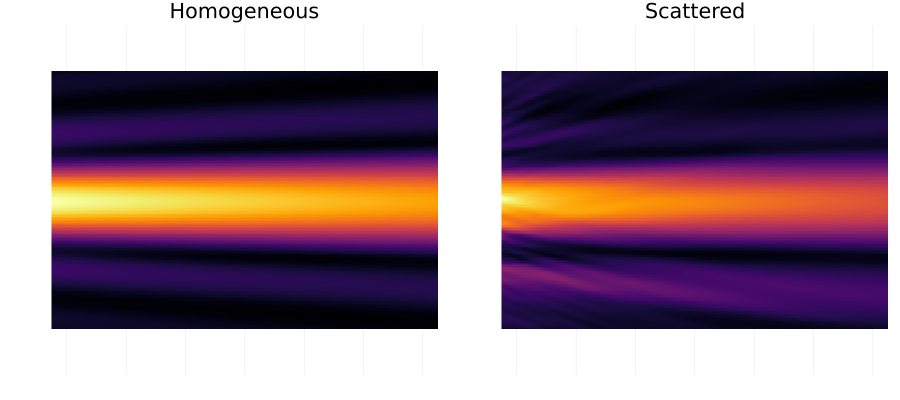

In [220]:
# data matrix
ky, kx = length(iwy), length(iwx)
X = zeros(ComplexF64, kx, ky, p)
x = view(X, fld(kx,2), fld(ky,2), :)
x .= randn(ComplexF64, p)
x ./= norm(x)
X = adapt(back, X)

Yscat = reshape(Gscat, n, k*p) * reshape(X, k*p)
Yhom = reshape(Ghom, n, k*p) * reshape(X, k*p)

kmscat = reshape(adjoint(reshape(Gscat, n, k*p)) * Yscat, k, p)
kmhom = reshape(adjoint(reshape(Ghom, n, k*p)) * Yhom, k, p)

imgscat = adapt(CPU(), reshape(sum(abs.(kmscat), dims=2), ky, kx))
imghom = adapt(CPU(), reshape(sum(abs.(kmhom), dims=2), ky, kx))

p1 = heatmap(iwx, iwy, imghom, title="Homogeneous", aspect_ratio = :equal, legend = false, axis=false)
p2 = heatmap(iwx, iwy, imgscat, title="Scattered", aspect_ratio = :equal, legend = false, axis=false)
plot(p1, p2, layout=(1,2), size=(900, 400))